# CIFAR-10 Image Classification using MobileNetV2

- Transfer learning (MobileNetV2)
- Training + validation tracking
- Evaluation metrics
- Confusion matrix
- Inference function

In [5]:
%matplotlib inline

**imports**

In [2]:
 import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


**Data Preprocessing**

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

### Load and Split Data

In [6]:
train_dataset_full = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)

train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full, [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

classes = train_dataset_full.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


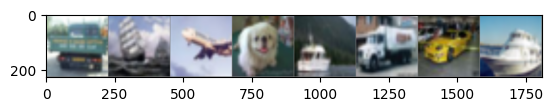

Labels: ['truck', 'ship', 'airplane', 'dog', 'ship', 'truck', 'automobile', 'ship']


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))

print("Labels:", [classes[labels[i]] for i in range(8)])

**Dataset**

In [9]:
train_dataset_full = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)

train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

train_dataset, val_dataset = random_split(
    train_dataset_full, [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

classes = train_dataset_full.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


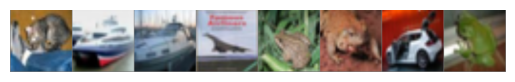

['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog']


In [10]:
import matplotlib.pyplot as plt
import torchvision
import numpy as np

dataiter = iter(test_loader)
images, labels = next(dataiter)

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

imshow(torchvision.utils.make_grid(images[:8]))
print([classes[i] for i in labels[:8]])

**Model (MobileNetV2)**

In [11]:
model = models.mobilenet_v2(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.last_channel, 10)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


**Loss & Optimizer**

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

**Training Loop**

In [ ]:
epochs = 5

train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}%")

**Training Curves**

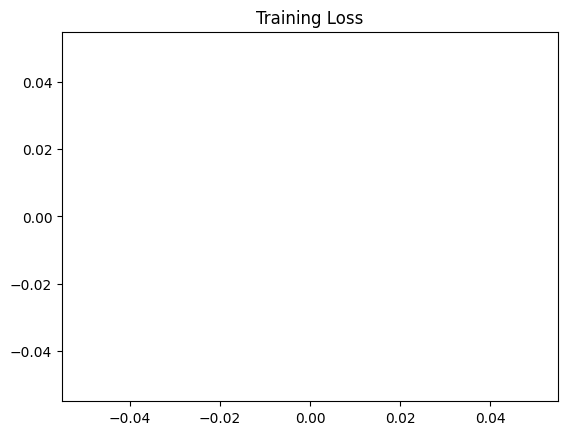

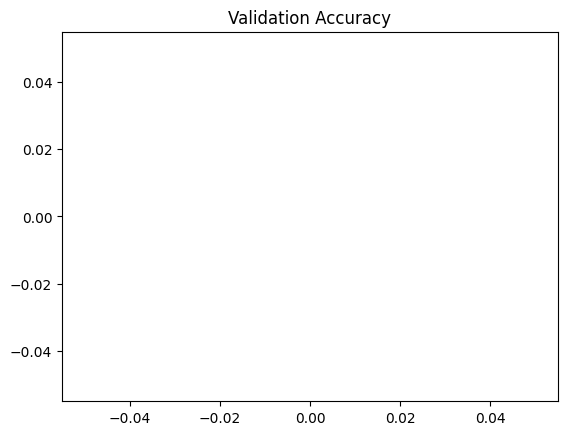

In [14]:
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.show()

plt.figure()
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.show()

**Model Evaluation**

In [15]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=classes))

              precision    recall  f1-score   support

    airplane       0.81      0.76      0.78      1000
  automobile       0.80      0.91      0.85      1000
        bird       0.86      0.50      0.63      1000
         cat       0.47      0.79      0.59      1000
        deer       0.67      0.74      0.70      1000
         dog       0.83      0.52      0.64      1000
        frog       0.81      0.81      0.81      1000
       horse       0.79      0.78      0.79      1000
        ship       0.82      0.86      0.84      1000
       truck       0.89      0.80      0.84      1000

    accuracy                           0.75     10000
   macro avg       0.77      0.75      0.75     10000
weighted avg       0.77      0.75      0.75     10000



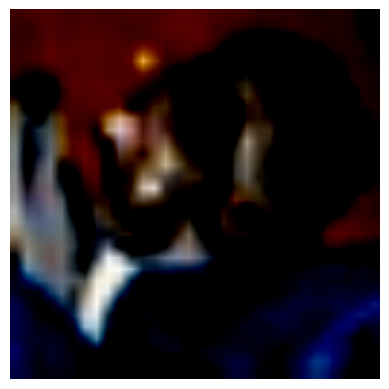

Actual: cat
Predicted: cat


In [16]:
model.eval()

images, labels = next(iter(test_loader))

img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img)
    _, pred = torch.max(output, 1)

plt.imshow(images[0].permute(1,2,0))
plt.axis("off")
plt.show()

print("Actual:", classes[labels[0]])
print("Predicted:", classes[pred.item()])

**Confusion Matrix**

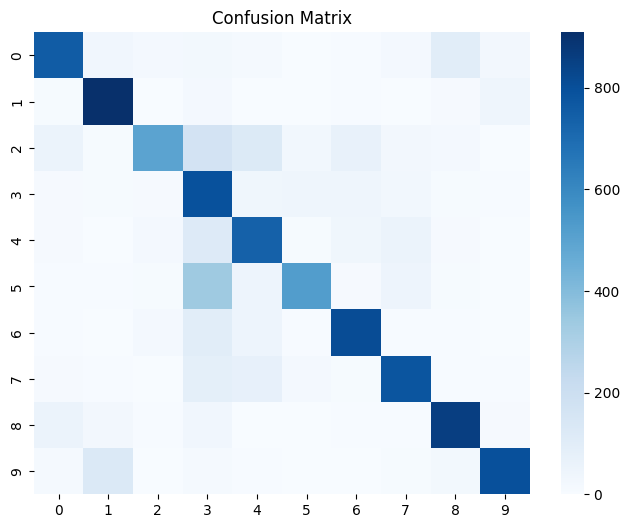

In [17]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

**Save Mode**

In [18]:
torch.save(model.state_dict(), "mobilenetv2_cifar10.pth")
print("Model saved successfully")

Model saved successfully


**Inference Function**

In [19]:
from PIL import Image

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

def predict(image_path):
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return classes[pred.item()]

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def show_prediction(image_path):
    image = Image.open(image_path)

    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")
    plt.show()

    print("Prediction:", predict(image_path))